In [1]:
import os
from pathlib import Path
import copy
import numpy as np
import torch

from pcdet.config import cfg, cfg_from_yaml_file
from pcdet.models import build_network, load_data_to_gpu
from pcdet.datasets import build_dataloader
from pcdet.utils import common_utils
import random

import math
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

/storage/home/hcoda1/9/spanse30/.conda/envs/mmlab/lib/python3.9/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/storage/home/hcoda1/9/spanse30/.conda/envs/mmlab/lib/python3.9/site-packages/spconv/pytorch/functional.py:97: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/storage/home/hcoda1/9/spanse30/.conda/envs/mmlab/lib/python3.9/site-packages/spconv/pytorch/functional.py:163: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/storage/home/hcoda1/9/spanse30/.conda/envs/mmlab/lib/python3.9/site-packages/spconv/pytorch/functional.py:243: Futur

In [2]:
CFG_FILE = 'tools/cfgs/waymo_models/centerpoint.yaml' 
CKPT = 'output/cfgs/custom_models/centerpoint_singleframe_waymo/default/ckpt/checkpoint_epoch_30.pth'  # <- put your ckpt here

cfg_from_yaml_file(CFG_FILE, cfg)
cfg.TAG = Path(CFG_FILE).stem
cfg.EXP_GROUP_PATH = 'centerpoint_waymo_demo'

logger = common_utils.create_logger()
logger.info(f'Loaded cfg from {CFG_FILE}')

test_set, test_loader, _ = build_dataloader(
    dataset_cfg=cfg.DATA_CONFIG,
    class_names=cfg.CLASS_NAMES,
    batch_size=1,
    dist=False,
    workers=4,
    logger=logger,
    training=False
)

len_test = len(test_set)
logger.info(f'Test set length: {len_test}')
model = build_network(
    model_cfg=cfg.MODEL,
    num_class=len(cfg.CLASS_NAMES),
    dataset=test_set
)

logger.info(f'Loading checkpoint from: {CKPT}')
model.load_params_from_file(filename=CKPT, logger=logger, to_cpu=False)
model.cuda()
model.eval()

data_iter = iter(test_loader)
batch_dict = next(data_iter)

load_data_to_gpu(batch_dict)

# Sanity check shapes
print('points:', batch_dict['points'].shape)         # [N, 5] -> [batch_idx, x, y, z, i]
print('voxels:', batch_dict['voxels'].shape)         # [V, T, C]
print('voxel_coords:', batch_dict['voxel_coords'].shape)  # [V, 4] -> [b, z, y, x]
print('voxel_num_points:', batch_dict['voxel_num_points'].shape)  # [V]

2025-12-26 21:52:04,357   INFO  Loaded cfg from tools/cfgs/waymo_models/centerpoint.yaml
2025-12-26 21:52:04,407   INFO  Loading Waymo dataset
2025-12-26 21:52:23,285   INFO  Total skipped info 0
2025-12-26 21:52:23,286   INFO  Total samples for Waymo dataset: 38597
2025-12-26 21:52:23,287   INFO  Test set length: 38597
2025-12-26 21:52:23,897   INFO  Loading checkpoint from: output/cfgs/custom_models/centerpoint_singleframe_waymo/default/ckpt/checkpoint_epoch_30.pth
2025-12-26 21:52:23,898   INFO  ==> Loading parameters from checkpoint output/cfgs/custom_models/centerpoint_singleframe_waymo/default/ckpt/checkpoint_epoch_30.pth to GPU
/storage/project/r-gchou3-0/spanse30/OpenPCDet/pcdet/models/detectors/detector3d_template.py:367: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https:

points: torch.Size([126501, 6])
voxels: torch.Size([75604, 5, 5])
voxel_coords: torch.Size([75604, 4])
voxel_num_points: torch.Size([75604])


In [3]:
dataset = test_set       # entire test/val split
infos = dataset.infos[0] # metadata for a single frame

In [4]:
def clone_batch(batch):
    """Clone a PCDet batch_dict so you can modify points without messing up the original."""
    out = copy.deepcopy(batch)
    # for k, v in batch_dict.items():
    #     if torch.is_tensor(v):
    #         out[k] = v.clone()
    #     else:
    #         out[k] = copy.deepcopy(v)
    return out
def get_points(batch):
    return batch['points']
def set_points(batch, new_points):
    batch['points'] = new_points

def get_ego_pose_global(dataset, i):
    infos = dataset.infos[i]
    pose = torch.tensor(infos['pose'])  # [4,4] numpy array
    return pose
def transform(T, xyz):
    N = xyz.shape[0]
    ones = torch.ones((N, 1), device=xyz.device, dtype=xyz.dtype)
    hom = torch.cat([xyz, ones], dim=1)  # [N,4]
    transformed = (T @ hom.T).t()[:, :3]  # [N,3]
    return transformed

In [ ]:
@dataclass
class MirrorModelParams:
    c0: float=2500.0
    beta: float = 1.25
    gamma: float = 3.5
    mu: float = 3.0
    sigma: float = 1.5

    k: float = 15.0
    b0min: float = -2.858
    b1: float = 0.1389
    c1: float = 0.1389
    b2: float = -0.3003
    b0max: float = -0.946 
    c2: float = 1.5390

    cX: float = 0.98
    dX : float = -0.05

    cR: float= 1.02
    nd: float = 0.88
    a1: float = 0.15
    a2: float = 0.08

    # tunable parameters for what kind of ghost is being created
    #standard deviations
    # sx = 0.6, sy = 0.6, sz = 0.3 gives good shape of car
    # 95% of points within +2*0.6, -2* 0.6 of mu_x. 2.4 m is appx length of car
    # similar for y and z
    sx: float = 0.6
    sy: float = 0.6
    sz: float = 0.3
    z0: float = 0.5   # put blob slightly above ground
def artifact_pos(d, theta_rad, p):
    X_artifact = p.cX*d*math.tan(2*theta_rad)+p.dX
    theta_deg = theta_rad
    R_artifact = p.cR*math.pow(d, p.nd)*(1 + p.a1*theta_deg + p.a2*theta_deg*theta_deg)
    return X_artifact, R_artifact
    
def N_artifact(d, theta, A, p):
    term = (d-p.mu)/(p.sigma+1e-12)
    gaussian = math.exp(-0.5 * term * term)
    N = p.c0*math.pow(A, p.beta)*math.pow(math.cos(theta), p.gamma)*gaussian
    return int(max(0, round(N)))

def P_app(d, theta_rad, A, p):
    dmin = p.b0min + p.b1*np.rad2deg(theta_rad) + p.b2*A
    dmax = p.b0max + p.c1*np.rad2deg(theta_rad) + p.c2*A
    # print(dmin, dmax)

    s1 = 1 / (1 + math.exp(-p.k*(d - dmin)))
    s2 = 1 / (1 + math.exp(p.k*(d - dmax)))
    P = s1 * s2
    return float(P)
#convert artifact position (R, X) to 3D centroid (x, y, z) (LiDAR coordinates)
def convert_to_3d_centroid(R, X, z0: float=0.5):
    y=X
    x = math.sqrt(max(0, R*R - y*y))

    #!might need to be torch
    return np.array([x, y, z0], dtype=np.float32)
def sample_intensity(points, centroid_s, N_artifact, radius: float = 2.0):
    xyz = points[:, 1:4] # assumes shape [N, 5] = [batch_id, x, y, z, intensity, elongation]
    intensity = points[:, 4]

    #euclidian distance between every point and center of phantom object
    #reshape center to (1, 3) so it can be subtracted from (N, 3) matrix xyz
    d = torch.norm(xyz - centroid_s[None, :], dim = 1)

    #find all points where d <3 and keep only intensity values for specified points
    # local neighborhood palette
    elong_val = points[:, 5] 
    neighbor_elong = elong_val[d < radius]
    print("neighbor_elong.numel(): ", neighbor_elong.numel())
    if neighbor_elong.numel() > 0:
        idx = torch.randint(0, neighbor_elong.numel(), (N_artifact,), device=points.device)
        elongation = neighbor_elong[idx].unsqueeze(1)
    else:
        elongation = torch.ones((N_artifact, 1), device=device) * 0.5 

    neighbor = intensity[d<radius]
    if neighbor.numel()>0:
        idx = torch.randint(0, neighbor.numel(), (N_artifact,), device = points.device)
        return torch.cat([neighbor[idx].unsqueeze(1), elongation], dim = 1) # [N_artifact, 1]
    
    #otheriwse return random gaussian noise around 0.5
    return torch.normal(mean = 0.5, std = 0.2, size=(N_artifact, 1), device=points.device).clamp(0.0, 1.0)

def inject_oaa(batch, centroid_s, N, params):
    if N<=0:
        print("N<0, returning unchanged dict")
        return batch

    points = get_points(batch)
    print("clean points shape:", points.shape)
    device = points.device
    dtype = points.dtype

    stddev = torch.tensor([params.sx, params.sy, params.sz],device=device, dtype=dtype)

    #scale each xyz by standard deviations. 
    # Result = N(0, 1) * stddev--> new variance = sigma^2
    noise = torch.randn((N, 3), device=device, dtype=dtype) * stddev[None, :]  # [N, 3]
    xyz_new = centroid_s[None, :].to(device = device, dtype=dtype) + noise  # [N, 3]    

    intensity_val = sample_intensity(points, centroid_s.to(device=device, dtype = dtype), N, radius=2.0)  # [N, 1]
    intensity_new = intensity_val.expand(N, 2)

    bcol = torch.zeros((N, 1), device=device, dtype=dtype)  # batch index = 0

    #!elongation
    new_points = torch.cat([bcol, xyz_new, intensity_new], dim=1)  # [N, 6]
    set_points(batch, torch.cat([points, new_points], dim=0))
    return batch, xyz_new

def revoxelize_batch(model, batch, dataset):
    voxel_config = None
    for proc in dataset.data_processor.data_processor_queue:
        if 'transform_points_to_voxels' in str(proc):
            voxel_config = proc.keywords['config']
            break
            
    if voxel_config is None:
        raise ValueError("Could not find 'transform_points_to_voxels' in the data_processor_queue.")


    # 2. Initialize the generator if it doesn't exist
    if not hasattr(dataset.data_processor, 'voxel_generator') or dataset.data_processor.voxel_generator is None:
        from pcdet.datasets.processor.data_processor import VoxelGeneratorWrapper
        dataset.data_processor.voxel_generator = VoxelGeneratorWrapper(
            vsize_xyz=voxel_config['VOXEL_SIZE'],
            coors_range_xyz=dataset.point_cloud_range,
            num_point_features=dataset.data_processor.num_point_features,
            max_num_points_per_voxel=voxel_config['MAX_POINTS_PER_VOXEL'],
            max_num_voxels=voxel_config['MAX_NUMBER_OF_VOXELS']['test'],
        )
    points_all = batch['points'].detach().cpu().numpy()
    points_to_voxel = points_all[:, 1:]
    res = dataset.data_processor.voxel_generator.generate(points_to_voxel)
    voxels, coords, num_points_per_voxel = res[0], res[1], res[2]
    batch_idx = np.zeros((coords.shape[0], 1), dtype=coords.dtype)
    coords = np.concatenate((batch_idx, coords), axis=1)
    device = batch['points'].device
    batch['voxels'] = torch.from_numpy(voxels).to(device=device).float()
    batch['voxel_coords'] = torch.from_numpy(coords).to(device=device).int()
    batch['voxel_num_points'] = torch.from_numpy(num_points_per_voxel).to(device=device).int()
    return batch

In [50]:
import math
T_gl = get_ego_pose_global(dataset, 0)
car_pos_g=T_gl[:3, 3]
car_forward_g = T_gl[:3, 0] # local x axis (forward) in global coordinates

mirror_pos_g = car_pos_g + torch.tensor([3, 2, 0])
theta = np.deg2rad(30)
d = torch.linalg.norm(mirror_pos_g - car_pos_g, ord=2, dim=-1)
A = 0.6
print("car_pos: ", car_pos_g)
print("mirror_pos: ", mirror_pos_g)

params = MirrorModelParams(mu=3, z0 = 0.8, sx = 0.2, sy = 0.2, sz = 0.2)

# for i in range(0, 40):
#     Ti = get_ego_pose_global(dataset, i)
#     sensor_pos_g = Ti[:3, 3]
#     d = torch.norm(mirror_pos_g - sensor_pos_g).item()
#     P = P_app(d, theta, A, params)
#     print(i, f"d={d:.2f}", f"P_app={P:.4f}")
print("d: ", d)
p = P_app(d, theta,A, params)
print("P_app =", p)

N = N_artifact(d, theta, A, params)
print("N_artifact =", N)

X_artifact, R_artifact = artifact_pos(d, theta, params)
print("X_artifact, R_artifact: ", X_artifact, R_artifact)



# centroid_np = convert_to_3d_centroid(R_artifact, X_artifact, z0=params.z0)
# centroid_s = torch.from_numpy(centroid_np).to(device=batch_dict['points'].device)
# print("centroid (x,y,z) [m] torch tensor =", centroid_s)

# # batch_clean = clone_batch(batch_dict)
# batch_mod = copy.deepcopy(batch_dict)
# device = batch_dict['points'].device
# #probabilistic trigger
# '''
# "The inherent randomness in real-world sensor physics... is captured by our empirically
# derived (P_app)... The probabilistic mechanism reflects the intermittent flicker of marginal
# detections observed in practice
# '''
# # u=random.random() # uniform distribution U(0, 1)
# # if u < p:
# batch_mod, xyz_new = inject_oaa(batch_mod, centroid_s, N, params)
# batch_mod = revoxelize_batch(model, batch_mod, dataset)
# print("Injected OAA blob with", N, "points.")
# print(f"Total non-empty voxels: {batch_mod['voxel_coords'].shape[0]}")

# # Are any voxels near your ghost?
# # Transform your ghost centroid to voxel coordinates
# vsize = torch.tensor([0.1, 0.1, 0.15]).to(device) # From your config
# pc_range = torch.tensor([-75.2, -75.2, -2, 75.2, 75.2, 4]).to(device)
# ghost_vox_coord = ((centroid_s - pc_range[:3]) / vsize).int()

# # Check if this coordinate exists in batch_mod['voxel_coords']
# # Note: coords are usually stored as [batch_idx, z, y, x]
# found = (batch_mod['voxel_coords'][:, 1:] == ghost_vox_coord.flip(0)).all(dim=1).any()
# print(f"Ghost voxel present in grid: {found}")
# # else:
# #     print("No OAA injection this frame (random gate).")

car_pos:  tensor([ 7213.2661, -1571.1233,   211.9570])
mirror_pos:  tensor([ 7216.2661, -1569.1233,   211.9570])
d:  tensor(3.6056)
P_app = 0.9996912695316513
N_artifact = 736
X_artifact, R_artifact:  tensor(6.0701) 3.469879132280454


In [62]:
params.cX*3*np.tan(2*theta) + params.dX

5.042229374252497

In [63]:
params.cR * 3**params.nd * (1+params.a1*theta + params.a2*theta*theta)

2.9515216941001214

In [64]:

params.b0min + params.b1*np.rad2deg(theta) + params.b2*A

1.1288199999999997

In [65]:
params.b0max + params.c1*np.rad2deg(theta) + params.c2*A

4.1444

In [69]:
theta = np.deg2rad(30)

In [85]:
ego_to_mirror = -1*(mirror_pos_g - car_pos_g)/torch.linalg.norm(mirror_pos_g - car_pos_g, ord=2, dim=-1)

R = np.array([[np.cos(theta), -1*np.sin(theta), 0],
              [np.sin(theta), np.cos(theta), 0],
              [0, 0, 1]])
R @ ego_to_mirror.detach().cpu().numpy()

array([-0.44322662, -0.89640962,  0.        ])

In [86]:
ego_to_mirror.detach().cpu().numpy()

array([-0.8320503, -0.5547002, -0.       ], dtype=float32)

In [45]:
torch.norm(car_forward_g)

tensor(1.)

In [46]:
# 1) Points increased?
print("points:", batch_dict['points'].shape, batch_mod['points'].shape)

# 2) Voxels changed?
print("voxels:", batch_dict['voxels'].shape, batch_mod['voxels'].shape)
print("voxels identical?", torch.equal(batch_dict['voxels'], batch_mod['voxels']))

# 3) Are injected xyz inside point cloud range?
pc_range = torch.tensor(dataset.point_cloud_range, device='cuda')
in_range = (
    (xyz_new[:,0] >= pc_range[0]) & (xyz_new[:,0] <= pc_range[3]) &
    (xyz_new[:,1] >= pc_range[1]) & (xyz_new[:,1] <= pc_range[4]) &
    (xyz_new[:,2] >= pc_range[2]) & (xyz_new[:,2] <= pc_range[5])
)
print("in range fraction:", in_range.float().mean().item())


points: torch.Size([126501, 6]) torch.Size([126726, 6])
voxels: torch.Size([75604, 5, 5]) torch.Size([75754, 5, 5])
voxels identical? False
in range fraction: 1.0


In [48]:
with torch.no_grad():
    pred_clean, _ = model.forward(batch_dict)
    pred_mod, _   = model.forward(batch_mod)
print("clean num boxes:", pred_clean[0]['pred_boxes'].shape[0])
print("mod   num boxes:", pred_mod[0]['pred_boxes'].shape[0])
# Look at the raw scores before filtering
raw_scores = pred_mod[0]['pred_scores']
print(f"Max confidence score in frame: {raw_scores.max().item():.4f}")

if raw_scores.max() < 0.1:
    print("The model sees something, but it's not 'car-like' enough. Try increasing N_artifact.")

clean num boxes: 97
mod   num boxes: 99
Max confidence score in frame: 0.9255


In [49]:
@torch.no_grad()
def best_box_near(pred, centroid_xyz, r_xy=2.0):
    boxes  = pred[0]['pred_boxes']   # (K,7) [x,y,z,dx,dy,dz,yaw]
    scores = pred[0]['pred_scores']  # (K,)
    labels = pred[0]['pred_labels']  # (K,) 1-based

    ctr = boxes[:, :2]
    cxy = centroid_xyz[:2].to(boxes.device).float()
    dist = torch.norm(ctr - cxy[None, :], dim=1)

    m = dist < r_xy
    if m.any():
        j = scores[m].argmax()
        # indices within masked subset
        idx = torch.nonzero(m, as_tuple=False).squeeze(1)[j]
        return {
            "score": float(scores[idx].item()),
            "label": int(labels[idx].item()),
            "box": boxes[idx].detach().cpu()
        }
    return None

# usage
phantom = torch.tensor(centroid_s, device='cuda')  # (3,)
hit_clean = best_box_near(pred_clean, phantom, r_xy=2.0)
hit_mod   = best_box_near(pred_mod, phantom, r_xy=2.0)
print("near clean:", hit_clean)
print("near mod  :", hit_mod)


near clean: None
near mod  : {'score': 0.16832485795021057, 'label': 2, 'box': tensor([-0.0794,  9.1540,  0.6064,  0.9464,  0.8813,  1.1284, -2.3871])}


/tmp/ipykernel_695894/2937130832.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phantom = torch.tensor(centroid_s, device='cuda')  # (3,)


In [ ]:
import torch

def summarize_preds(tag, pred_dict, phantom_xyz):
    boxes = pred_dict.get('pred_boxes', None)
    scores = pred_dict.get('pred_scores', None)
    labels = pred_dict.get('pred_labels', None)

    if boxes is None:
        print(f"[{tag}] pred_boxes missing keys={list(pred_dict.keys())}")
        return

    n = boxes.shape[0]
    print(f"[{tag}] #boxes = {n}")
    if n == 0:
        return

    print(f"[{tag}] scores: min={scores.min().item():.3f}  max={scores.max().item():.3f}")
    # nearest box in XY, regardless of radius
    centers = boxes[:, 0:3]
    dxy = torch.norm(centers[:, :2] - phantom_xyz[:2], dim=1)
    j = torch.argmin(dxy).item()
    print(f"[{tag}] nearest box: dxy={dxy[j].item():.3f} m, center={centers[j].tolist()}, score={scores[j].item():.3f}, label={int(labels[j].item())}")

# use your centroid tensor here (same device)
phantom = centroid_s.squeeze(0) if centroid_s.ndim == 2 else centroid_s
summarize_preds("clean", pred_clean[0], phantom)
summarize_preds("mod",   pred_mod[0],   phantom)


In [ ]:
torch.equal(pred_clean[0]['pred_scores'], pred_mod[0]['pred_scores']) 

In [ ]:
centroid_s

In [ ]:
batch_dict['metadata']

In [ ]:
# with torch.no_grad():
#     pred_clean, _ = model.forward(batch_dict)
from pcdet.ops.iou3d_nms import iou3d_nms_utils

# GT: [B, M, 8] -> [x,y,z,dx,dy,dz,heading,label]
gt = batch_dict['gt_boxes'][0]
gt_boxes = gt[gt[:, -1] > 0][:, :7].cuda()  # filter padded, drop class

pred_boxes = pred_clean[0]['pred_boxes']  # Tensor [N, 7 or 9]
pred_boxes = pred_boxes[:, :7]            # drop extra dims if present

ious = iou3d_nms_utils.boxes_iou3d_gpu(gt_boxes, pred_boxes)
print(ious.max(dim=1).values)  # best IoU per GT


In [ ]:
batch_dict['voxels'].shape

In [ ]:
points = batch_mod['points'].detach().cpu().numpy()
points_to_voxel = points[:, 1:]

In [ ]:
vars(dataset.data_processor)

In [ ]:
dataset.data_processor.data_processor_queue

In [ ]:
dataset.data_processor.data_processor_queue[2]

In [ ]:
voxel_config = None
for proc in dataset.data_processor.data_processor_queue:
    if 'transform_points_to_voxels' in str(proc):
        voxel_config = proc.keywords['config']
        break
        
if voxel_config is None:
    raise ValueError("Could not find 'transform_points_to_voxels' in the data_processor_queue.")


# 2. Initialize the generator if it doesn't exist
if not hasattr(dataset.data_processor, 'voxel_generator') or dataset.data_processor.voxel_generator is None:
    from pcdet.datasets.processor.data_processor import VoxelGeneratorWrapper
    dataset.data_processor.voxel_generator = VoxelGeneratorWrapper(
        vsize_xyz=voxel_config['VOXEL_SIZE'],
        coors_range_xyz=dataset.point_cloud_range,
        num_point_features=dataset.data_processor.num_point_features,
        max_num_points_per_voxel=voxel_config['MAX_POINTS_PER_VOXEL'],
        max_num_voxels=voxel_config['MAX_NUMBER_OF_VOXELS']['test'],
    )
res = dataset.data_processor.voxel_generator.generate(points_to_voxel)
voxels, coords, num_points_per_voxel = res[0], res[1], res[2]
batch_idx = np.zeros((coords.shape[0], 1), dtype=coords.dtype)
coords = np.concatenate((batch_idx, coords), axis=1)
device = batch_dict['points'].device
batch_dict['voxels'] = torch.from_numpy(voxels).to(device=device).float()
batch_dict['voxel_coords'] = torch.from_numpy(coords).to(device=device).int()
batch_dict['voxel_num_points'] = torch.from_numpy(num_points_per_voxel).to(device=device).int()


In [ ]:
res[0].shape

In [ ]:
batch_dict['voxels'].shape

In [ ]:
batch_dict['voxels'].shape

In [ ]:
batch_dict['voxel_coords'].shape

In [ ]:
batch_dict['voxel_num_points']

In [ ]:
res[2]

In [ ]:
batch_dict['points'].device

In [ ]:
import plotly.graph_objects as go
import numpy as np

# Animate frames 0-197 from the dataset (same sequence assumed)
start_idx = 0
end_idx = 0
max_points = 150000  # downsample per frame for speed; raise/lower as needed
rng = np.random.default_rng(0)

frame_points = []
mins = []
maxs = []

for i in range(start_idx, end_idx + 1):
    info = dataset.infos[i]
    seq = info['point_cloud']['lidar_sequence']
    sample_idx = info['point_cloud']['sample_idx']
    # pts = dataset.get_lidar(seq, sample_idx)[:, :3]
    pts = batch_mod['points'].cpu().numpy()[:, 1:4]
    if pts.shape[0] > max_points:
        sel = rng.choice(pts.shape[0], size=max_points, replace=False)
        pts = pts[sel]

    frame_points.append(pts)
    mins.append(pts.min(axis=0))
    maxs.append(pts.max(axis=0))

global_min = np.min(np.vstack(mins), axis=0)
global_max = np.max(np.vstack(maxs), axis=0)

def make_scatter(pts):
    return go.Scatter3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        mode='markers',
        marker=dict(size=1, color=pts[:, 2], colorscale='Viridis', opacity=0.6),
    )

frames = [
    go.Frame(data=[make_scatter(pts)], name=str(i))
    for i, pts in zip(range(start_idx, end_idx + 1), frame_points)
]


fig = go.Figure(
    data=[make_scatter(frame_points[0])],
    frames=frames,
)

fig.update_layout(
    title=f'Waymo sequence frames {start_idx}-{end_idx}',
    scene=dict(
        xaxis=dict(range=[global_min[0], global_max[0]], title='x'),
        yaxis=dict(range=[global_min[1], global_max[1]], title='y'),
        zaxis=dict(range=[global_min[2], global_max[2]], title='z'),
        aspectmode='data',
    ),
    margin=dict(l=0, r=0, t=30, b=0),
    updatemenus=[{
        'type': 'buttons',
        'showactive': True,
        'x': 0.1,
        'y': 0,
        'pad': {'r': 10, 't': 70},
        'buttons': [
            {
                'label': 'Play',
                'method': 'animate',
                'args': [None, {'frame': {'duration': 500, 'redraw': True}, 'fromcurrent': True}],
            },
            {
                'label': 'Pause',
                'method': 'animate',
                'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}],
            },
        ],
    }],
    sliders=[{
        'x': 0.1,
        'y': 0,
        'len': 0.9,
        'steps': [
            {
                'method': 'animate',
                'args': [[str(i)], {'frame': {'duration': 5, 'redraw': True}, 'mode': 'immediate'}],
                'label': str(i),
            }
            for i in range(start_idx, end_idx + 1)
        ],
    }],
)

fig.show()


In [ ]:
#!pose might be on cpu
def compute_theta_d(ego_pose, mirror):
    device = ego_pose.device #!questionable line
    center_g = mirror.center_g.to(device)
    normal_g = mirror.normal_g.to(device)

    position = ego_pose[:3, 3]  # [3,]
    look_vec = center_g - position
    #!make sure look_vec is on the same device as ego_pose, both torch tensors
    d = torch.norm(look_vec).item() 

    #direction vector pointing at mirror
    look_hat = look_vec / (torch.norm(look_vec) + 1e-12)  # [3,]

    # dot product A.B = cos(angle between A, B)
    # incidence angle between incoming ray direction and normal:
    # angle = arccos(|dot(look_hat, normal)|)
    cosang = torch.clamp(torch.abs(torch.dot(look_hat, normal_g)), 0.0, 1.0)
    theta = torch.acos(cosang).item() # radians
    return d, theta

In [ ]:
# def rot_about_z(theta_rad: float, device=None, dtype=torch.float32):
#     c = math.cos(theta_rad); s = math.sin(theta_rad)
#     R = torch.tensor([[c, -s, 0.0],
#                       [s,  c, 0.0],
#                       [0.0, 0.0, 1.0]], device=device, dtype=dtype)
#     return R

# theta_target_deg = 60
# theta_target = math.radians(theta_target_deg)

# # mirror should "mostly face" the car, but rotated in yaw so incidence is ~45°
# Rz = rot_about_z(theta_target, device=car_forward_g.device, dtype=car_forward_g.dtype)
# mirror_normal = (Rz @ (-car_forward_g))
# mirror_normal = mirror_normal / (mirror_normal.norm() + 1e-12)

In [ ]:
distance_ahead = 6
car0_left_g = T_gl[:3, 1]
car0_left_g = car0_left_g / (car0_left_g.norm() + 1e-12)

lateral_offset = 2.0  # meters to the left
mirror_center = car_pos_g + (car_forward_g * distance_ahead) + car0_left_g * lateral_offset

#!important: freeze position of mirror if doing over several frames
mirror = VirtualMirror(
    center_g = mirror_center,
    normal_g = mirror_normal,
    area_m2 = 0.6 #larger area = stronger attack
)

d, theta = compute_theta_d(T_gl, mirror)
print("d [m] =", d, "theta [deg] =", theta * 180/math.pi)

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
theta_deg = 30.0                  # mirror tilt angle (degrees)
theta = np.deg2rad(theta_deg)

lidar_pos = np.array([0.0, 0.0])  # LiDAR at origin
mirror_pos = np.array([3.0, 2.0]) # mirror location (meters)

# -----------------------------
# Incoming ray direction
# -----------------------------
i_hat = (lidar_pos - mirror_pos)
i_hat = i_hat / np.linalg.norm(i_hat)

i_hat


array([-0.83205029, -0.5547002 ])

In [91]:

# -----------------------------
# Mirror normal (zero tilt)
# -----------------------------
n0_hat = i_hat.copy()

# -----------------------------
# Apply mirror tilt (yaw about Z)
# -----------------------------
Rz = np.array([
    [ np.cos(theta), -np.sin(theta)],
    [ np.sin(theta),  np.cos(theta)]
])

n_hat = Rz @ n0_hat

n_hat

array([-0.44322659, -0.89640961])

In [92]:

# -----------------------------
# Reflected ray direction
# -----------------------------
r_hat = i_hat - 2 * np.dot(i_hat, n_hat) * n_hat
r_hat = r_hat / np.linalg.norm(r_hat)

r_hat

array([-0.06435931,  0.99792679])

In [ ]:

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7, 7))

# LiDAR
plt.scatter(*lidar_pos, c='k', s=80)
plt.text(0.05, 0.05, "LiDAR", fontsize=11)

# Mirror
plt.scatter(*mirror_pos, c='orange', s=80)
plt.text(mirror_pos[0]+0.05, mirror_pos[1]+0.05, "Mirror", fontsize=11)

# Incoming ray
plt.arrow(
    mirror_pos[0], mirror_pos[1],
    i_hat[0], i_hat[1],
    width=0.01, head_width=0.15,
    length_includes_head=True,
    color='blue'
)
plt.text(mirror_pos[0]+i_hat[0], mirror_pos[1]+i_hat[1], "Incoming ray", color='blue')

# Zero-tilt normal
plt.arrow(
    mirror_pos[0], mirror_pos[1],
    n0_hat[0], n0_hat[1],
    width=0.01, head_width=0.15,
    length_includes_head=True,
    color='green'
)
plt.text(mirror_pos[0]+n0_hat[0], mirror_pos[1]+n0_hat[1], "Normal (θ=0°)", color='green')

# Tilted normal
plt.arrow(
    mirror_pos[0], mirror_pos[1],
    n_hat[0], n_hat[1],
    width=0.01, head_width=0.15,
    length_includes_head=True,
    color='red'
)
plt.text(mirror_pos[0]+n_hat[0], mirror_pos[1]+n_hat[1], f"Normal (θ={theta_deg}°)", color='red')

# Reflected ray
plt.arrow(
    mirror_pos[0], mirror_pos[1],
    r_hat[0]*2, r_hat[1]*2,
    width=0.01, head_width=0.15,
    length_includes_head=True,
    color='purple'
)
plt.text(mirror_pos[0]+r_hat[0]*2, mirror_pos[1]+r_hat[1]*2, "Reflected ray", color='purple')

# Axes formatting
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

plt.xlabel("X (forward)")
plt.ylabel("Y (left)")
plt.title("Mirror Tilt Geometry (Top-Down View)")
plt.axis("equal")
plt.grid(True)
plt.xlim(-1, 6)
plt.ylim(-1, 6)

plt.show()


-3.8320502943378436 -2.5547001962252294
-3.4432265940102775 -2.8964096085841833
Artifact centroid: [2.88711398 1.92474265]


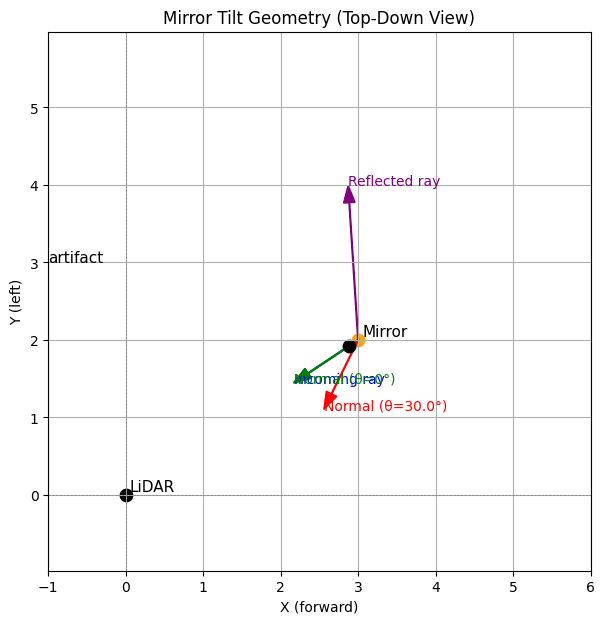

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
theta_deg = 30.0                  # mirror tilt angle (degrees)
theta = np.deg2rad(theta_deg)

lidar_pos = np.array([0.0, 0.0])  # LiDAR at origin
mirror_pos = np.array([3.0, 2.0]) # mirror location (meters)

# -----------------------------
# Incoming ray direction
# -----------------------------
i_hat = (lidar_pos - mirror_pos)
i_hat = i_hat / np.linalg.norm(i_hat)

# -----------------------------
# Mirror normal (zero tilt)
# -----------------------------
n0_hat = i_hat.copy()

# -----------------------------
# Apply mirror tilt (yaw about Z)
# -----------------------------
Rz = np.array([
    [ np.cos(theta), -np.sin(theta)],
    [ np.sin(theta),  np.cos(theta)]
])

n_hat = Rz @ n0_hat

# -----------------------------
# Reflected ray direction
# -----------------------------
r_hat = i_hat - 2 * np.dot(i_hat, n_hat) * n_hat
r_hat = r_hat / np.linalg.norm(r_hat)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7, 7))

# LiDAR
plt.scatter(*lidar_pos, c='k', s=80)
plt.text(0.05, 0.05, "LiDAR", fontsize=11)

# Mirror
plt.scatter(*mirror_pos, c='orange', s=80)
plt.text(mirror_pos[0]+0.05, mirror_pos[1]+0.05, "Mirror", fontsize=11)

# Incoming ray
plt.arrow(
    mirror_pos[0], mirror_pos[1],
    i_hat[0], i_hat[1],
    width=0.01, head_width=0.15,
    length_includes_head=True,
    color='blue'
)
plt.text(mirror_pos[0]+i_hat[0], mirror_pos[1]+i_hat[1], "Incoming ray", color='blue')
print(-mirror_pos[0]+i_hat[0], -mirror_pos[1]+i_hat[1])

# Zero-tilt normal
plt.arrow(
    mirror_pos[0], mirror_pos[1],
    n0_hat[0], n0_hat[1],
    width=0.01, head_width=0.15,
    length_includes_head=True,
    color='green'
)
plt.text(mirror_pos[0]+n0_hat[0], mirror_pos[1]+n0_hat[1], "Normal (θ=0°)", color='green')

# Tilted normal
plt.arrow(
    mirror_pos[0], mirror_pos[1],
    n_hat[0], n_hat[1],
    width=0.01, head_width=0.15,
    length_includes_head=True,
    color='red'
)
plt.text(mirror_pos[0]+n_hat[0], mirror_pos[1]+n_hat[1], f"Normal (θ={theta_deg}°)", color='red')
print(-mirror_pos[0]+n_hat[0], -mirror_pos[1]+n_hat[1])

# Reflected ray
plt.arrow(
    mirror_pos[0], mirror_pos[1],
    r_hat[0]*2, r_hat[1]*2,
    width=0.01, head_width=0.15,
    length_includes_head=True,
    color='purple'
)
plt.text(mirror_pos[0]+r_hat[0]*2, mirror_pos[1]+r_hat[1]*2, "Reflected ray", color='purple')


d = np.linalg.norm(mirror_pos - lidar_pos)

# Eq. (4) parameters (example values)
c_R = 1.02
n_d = 0.88
a1  = 0.15
a2  = 0.08

R_artifact = c_R * (d ** n_d) * (1 + a1*theta + a2*(theta**2))
u = (mirror_pos - lidar_pos) / d

C_artifact = lidar_pos + R_artifact * u
print("Artifact centroid:", C_artifact)

plt.scatter(*C_artifact, c='k', s=80)
plt.text(-1, 3, "artifact", fontsize=11)

# Axes formatting
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)

plt.xlabel("X (forward)")
plt.ylabel("Y (left)")
plt.title("Mirror Tilt Geometry (Top-Down View)")
plt.axis("equal")
plt.grid(True)
plt.xlim(-1, 6)
plt.ylim(-1, 6)

plt.show()


In [95]:
r_hat

array([-0.06435931,  0.99792679])

In [107]:
u*R_artifact

array([2.88711398, 1.92474265])

In [102]:
# -----------------------------
# Artifact centroid (paper-consistent)
# -----------------------------
d = np.linalg.norm(mirror_pos - lidar_pos)

# Eq. (4) parameters (example values)
c_R = 1.02
n_d = 0.88
a1  = 0.15
a2  = 0.08

R_artifact = c_R * (d ** n_d) * (1 + a1*theta + a2*(theta**2))

C_artifact = lidar_pos + R_artifact * r_hat
print("Artifact centroid:", C_artifact)


Artifact centroid: [-0.22331904  3.46268537]


In [100]:
C_artifact

array([-0.22331904,  3.46268534])